<a href="https://colab.research.google.com/github/JOY-246/C_V_P_R/blob/main/CNN_22_49903_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import random_split

2. Load & Preprocess Dataset

In [12]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

# Split into train + validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

3. Visualize Sample Images

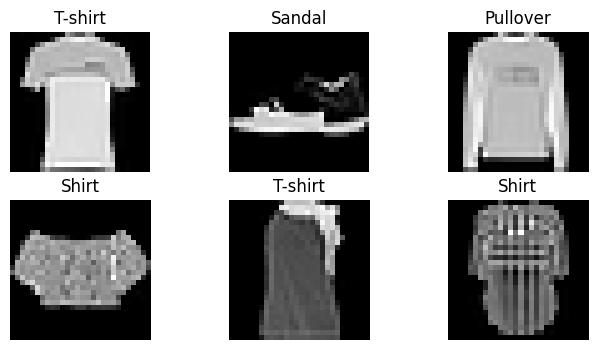

In [13]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

4. Define CNN Models
🔹 Model A (WITH BatchNorm + Dropout)

In [14]:
class CNN_BN(nn.Module):
    def __init__(self):
        super(CNN_BN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

🔹 Model B (WITHOUT BatchNorm & Dropout)

In [15]:
class CNN_Simple(nn.Module):
    def __init__(self):
        super(CNN_Simple, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

5. Model Summary (Architecture)

In [16]:
from torchsummary import summary

model = CNN_BN()
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
            Conv2d-5           [-1, 64, 14, 14]          18,496
       BatchNorm2d-6           [-1, 64, 14, 14]             128
              ReLU-7           [-1, 64, 14, 14]               0
         MaxPool2d-8             [-1, 64, 7, 7]               0
            Linear-9                  [-1, 128]         401,536
             ReLU-10                  [-1, 128]               0
          Dropout-11                  [-1, 128]               0
           Linear-12                   [-1, 10]           1,290
Total params: 421,834
Trainable params: 421,834
Non-trainable params: 0
-------------------------------

6. Training Function (Reusable)

In [17]:
def train_model(model, train_loader, val_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    train_losses, val_losses = [], []
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_losses.append(running_loss)
        train_acc.append(100 * correct / total)

        # Validation
        model.eval()
        v_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)

                v_loss += loss.item()
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_losses.append(v_loss)
        val_acc.append(100 * correct / total)

        scheduler.step()

        print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.2f}%, Val Acc={val_acc[-1]:.2f}%")

    return train_losses, val_losses, train_acc, val_acc

7. Train BOTH Models

In [18]:
model_bn = CNN_BN()
model_simple = CNN_Simple()

print("Training Model WITH BatchNorm & Dropout")
bn_loss, bn_vloss, bn_acc, bn_vacc = train_model(model_bn, train_loader, val_loader)

print("\nTraining Model WITHOUT BatchNorm & Dropout")
s_loss, s_vloss, s_acc, s_vacc = train_model(model_simple, train_loader, val_loader)

Training Model WITH BatchNorm & Dropout
Epoch 1: Train Acc=79.95%, Val Acc=88.13%
Epoch 2: Train Acc=85.59%, Val Acc=88.50%
Epoch 3: Train Acc=87.35%, Val Acc=89.87%
Epoch 4: Train Acc=88.23%, Val Acc=89.89%
Epoch 5: Train Acc=88.95%, Val Acc=90.58%
Epoch 6: Train Acc=90.72%, Val Acc=91.39%
Epoch 7: Train Acc=91.39%, Val Acc=91.51%
Epoch 8: Train Acc=91.46%, Val Acc=91.58%
Epoch 9: Train Acc=91.60%, Val Acc=91.59%
Epoch 10: Train Acc=91.81%, Val Acc=91.67%

Training Model WITHOUT BatchNorm & Dropout
Epoch 1: Train Acc=82.53%, Val Acc=86.64%
Epoch 2: Train Acc=88.73%, Val Acc=88.88%
Epoch 3: Train Acc=90.30%, Val Acc=90.09%
Epoch 4: Train Acc=91.40%, Val Acc=90.29%
Epoch 5: Train Acc=92.40%, Val Acc=91.57%
Epoch 6: Train Acc=94.31%, Val Acc=92.38%
Epoch 7: Train Acc=94.64%, Val Acc=92.36%
Epoch 8: Train Acc=94.80%, Val Acc=92.24%
Epoch 9: Train Acc=95.00%, Val Acc=92.47%
Epoch 10: Train Acc=95.06%, Val Acc=92.41%


8. Plot Results

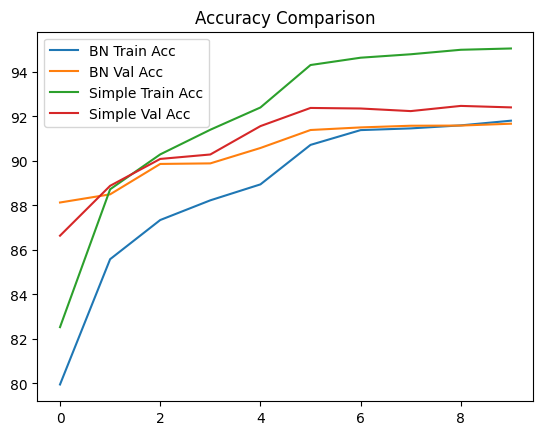

In [19]:
plt.plot(bn_acc, label="BN Train Acc")
plt.plot(bn_vacc, label="BN Val Acc")
plt.plot(s_acc, label="Simple Train Acc")
plt.plot(s_vacc, label="Simple Val Acc")
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

9. Test Evaluation (Best Model)

In [20]:
model = model_bn
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

10. Confusion Matrix

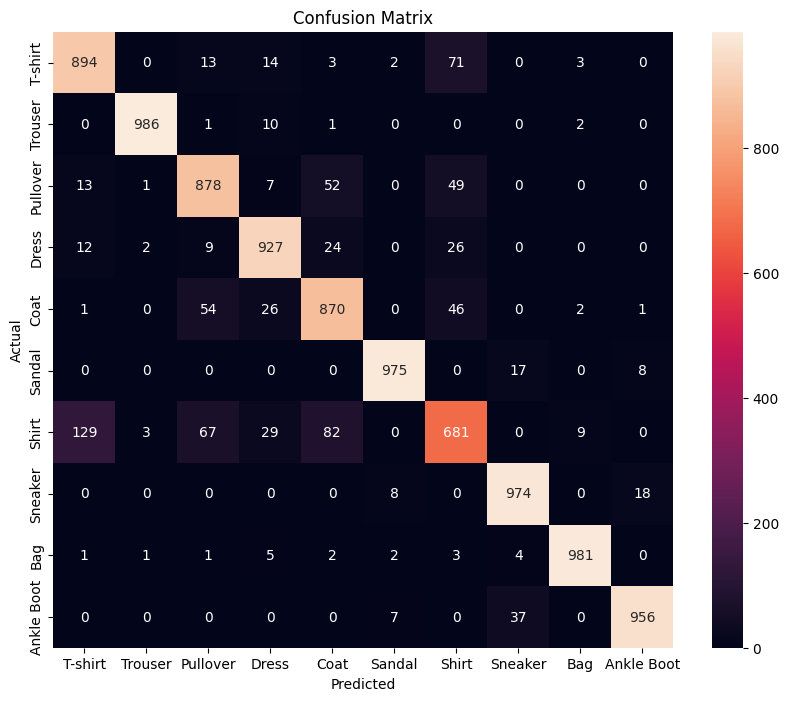

In [21]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

11. Classification Report

In [22]:
print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

     T-shirt       0.85      0.89      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.86      0.88      0.87      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.84      0.87      0.86      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.78      0.68      0.73      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.97      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



12. Save Model

In [23]:
torch.save(model.state_dict(), "cnn_fashion_mnist.pth")